In [1]:
!pip install pybaseball

from pybaseball import statcast_pitcher
from pybaseball import playerid_lookup
import pandas as pd

playerid_lookup('arrighetti', 'spencer')

Gathering player lookup table. This may take a moment.


,name_last,name_first,key_mlbam,key_retro,key_bbref,key_fangraphs,mlb_played_first,mlb_played_last
0,arrighetti,spencer,681293,arris001,arrigsp01,29921,2024.0,2026.0


In [1]:
from pybaseball import statcast_pitcher
from pybaseball import playerid_lookup
import pandas as pd

playerid_lookup('arrighetti', 'spencer')

Gathering player lookup table. This may take a moment.


,name_last,name_first,key_mlbam,key_retro,key_bbref,key_fangraphs,mlb_played_first,mlb_played_last
0,arrighetti,spencer,681293,arris001,arrigsp01,29921,2024.0,2026.0


In [2]:
# 2024 시즌 개막 ~ 2026년 5월 30일 
df = statcast_pitcher(
    start_dt='2024-03-20',
    end_dt='2026-05-30',
    player_id=681293
)

print(df.shape)
df['game_date'].min(), df['game_date'].max()

Gathering Player Data
(4361, 118)


('2024-04-10', '2026-05-28')

In [3]:
df['game_date'] = pd.to_datetime(df['game_date'])

df['season'] = df['game_date'].dt.year

print(df['season'].value_counts().sort_index())

season
2024    2509
2025     945
2026     907
Name: count, dtype: int64


In [4]:
df_2024 = df[df['season'] == 2024].copy()
df_2025 = df[df['season'] == 2025].copy()
df_2026 = df[df['season'] == 2026].copy()

print(f"2024 시즌: {len(df_2024)}행")
print(f"2025 시즌: {len(df_2025)}행")
print(f"2026 시즌: {len(df_2026)}행")
print(f"전체: {len(df)}행")

2024 시즌: 2509행
2025 시즌: 945행
2026 시즌: 907행
전체: 4361행


In [5]:
df_2024.head()

,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches,season
1852,FF,2024-09-27,94.8,-1.93,5.13,"Arrighetti, Spencer",680757,681293,walk,ball,...,1.23,0.47,-0.47,29.9,NaN,NaN,NaN,NaN,NaN,2024
1853,FF,2024-09-27,95.2,-1.83,5.05,"Arrighetti, Spencer",680757,681293,NaN,foul,...,1.18,0.84,-0.84,29.2,0.724214,18.118737,36.54684,37.069259,18.421035,2024
1854,FF,2024-09-27,95.3,-1.80,5.04,"Arrighetti, Spencer",680757,681293,NaN,called_strike,...,1.33,1.01,-1.01,23.8,NaN,NaN,NaN,NaN,NaN,2024
1855,FC,2024-09-27,88.7,-2.11,4.93,"Arrighetti, Spencer",680757,681293,NaN,ball,...,2.38,-0.49,0.49,21.0,NaN,NaN,NaN,NaN,NaN,2024
1856,FC,2024-09-27,87.4,-2.14,4.85,"Arrighetti, Spencer",680757,681293,NaN,ball,...,2.50,-0.46,0.46,21.6,NaN,NaN,NaN,NaN,NaN,2024


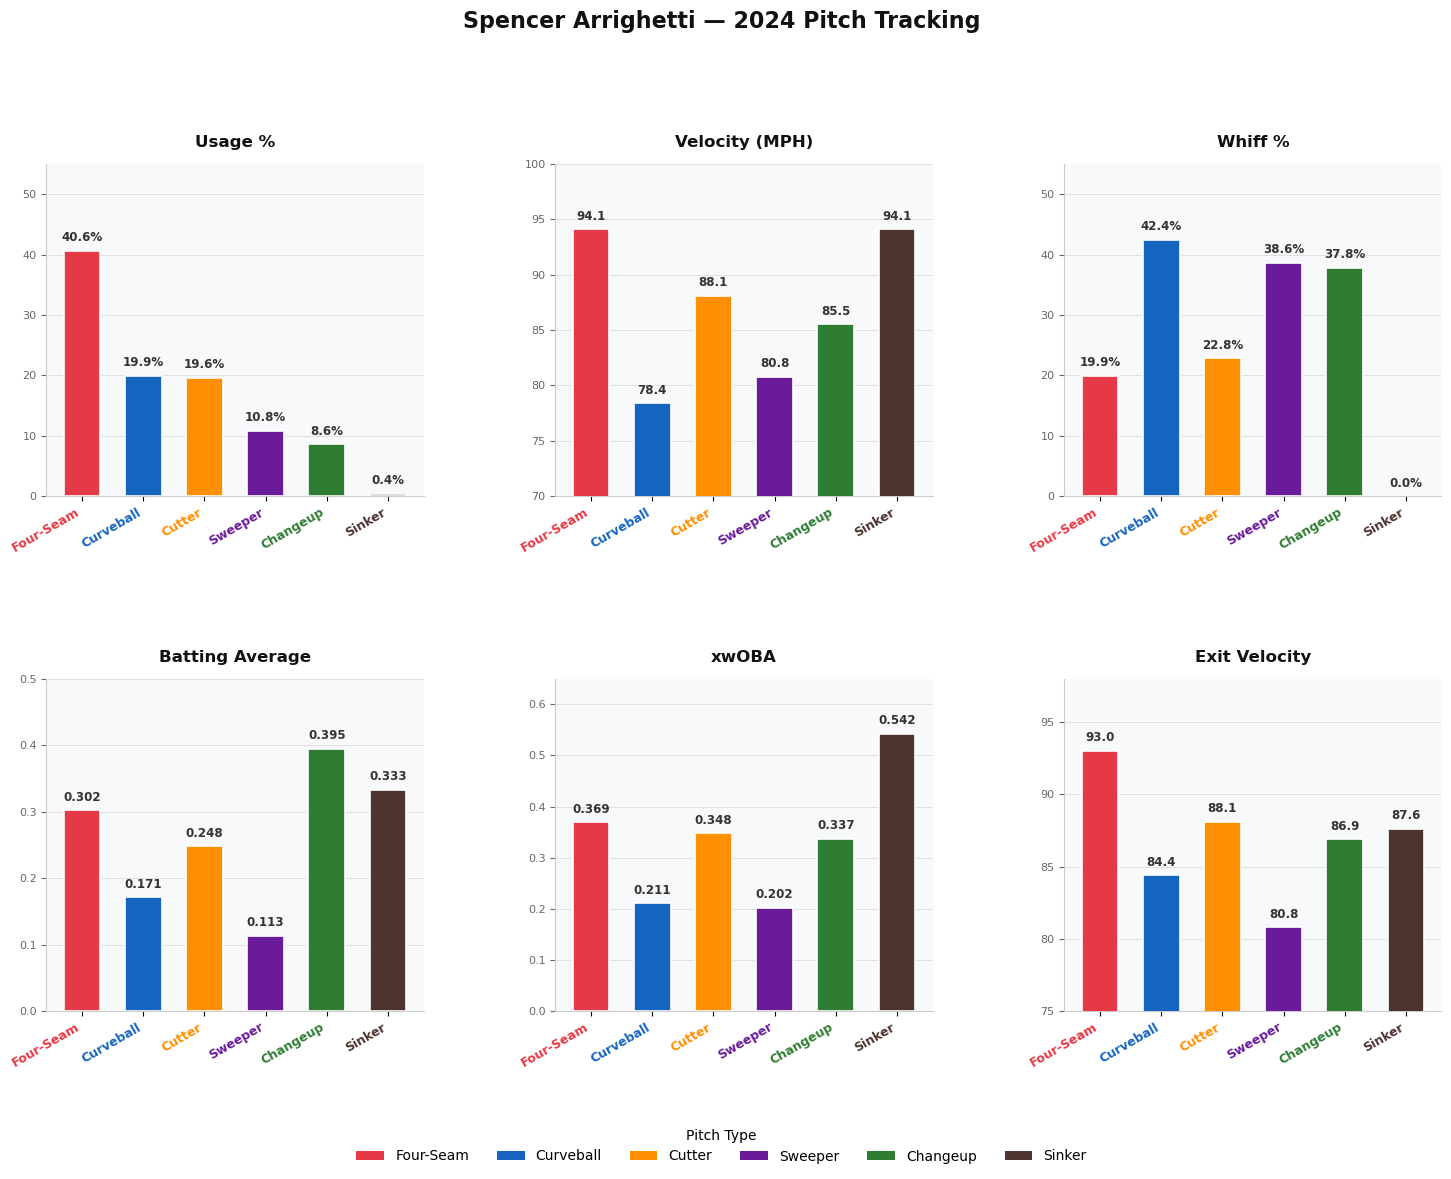

In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

data_2024 = {
    'Pitch'  : ['Four-Seam', 'Curveball', 'Cutter', 'Sweeper', 'Changeup', 'Sinker'],
    'Usage%' : [40.6, 19.9, 19.6, 10.8, 8.6, 0.4],
    'MPH'    : [94.1, 78.4, 88.1, 80.8, 85.5, 94.1],
    'Whiff%' : [19.9, 42.4, 22.8, 38.6, 37.8, 0.0],
    'BA'     : [.302, .171, .248, .113, .395, .333],
    'xwOBA'  : [.369, .211, .348, .202, .337, .542],
    'EV'     : [93.0, 84.4, 88.1, 80.8, 86.9, 87.6],
}

df_plot = pd.DataFrame(data_2024).set_index('Pitch')


pitch_colors = {
    'Four-Seam' : '#E63946',
    'Curveball' : '#1565C0',
    'Cutter'    : '#FF8F00',
    'Sweeper'   : '#6A1B9A',
    'Changeup'  : '#2E7D32',
    'Sinker'    : '#4E342E',
}
colors = [pitch_colors[p] for p in df_plot.index]

fig = plt.figure(figsize=(18, 11))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.35)
axes = [fig.add_subplot(gs[i//3, i%3]) for i in range(6)]

plot_data = [
    ('Usage%', 'Usage %',         '%',  [0, 55]),
    ('MPH',    'Velocity (MPH)',  'mph', [70, 100]),
    ('Whiff%', 'Whiff %',        '%',   [0, 55]),
    ('BA',     'Batting Average', '',   [0, 0.50]),
    ('xwOBA',  'xwOBA',          '',    [0, 0.65]),
    ('EV',     'Exit Velocity',  'mph', [75, 98]),
]

for ax, (col, title, unit, ylim) in zip(axes, plot_data):
    ax.set_facecolor('#F8F9FA')

    bars = ax.bar(
        range(len(df_plot.index)),
        df_plot[col],
        color=colors,
        width=0.6,
        edgecolor='white',
        linewidth=1.2,
        zorder=3
    )

    
    for bar, val in zip(bars, df_plot[col]):
        if unit == '%':
            label = f"{val}%"
        elif unit == 'mph':
            label = f"{val}"
        else:
            label = f"{val:.3f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + (ylim[1] - ylim[0]) * 0.02,
            label,
            ha='center', va='bottom',
            fontsize=8.5, color='#333333', fontweight='bold'
        )

    ax.set_title(title, color='#111111', fontsize=12,
                 fontweight='bold', pad=12)
    ax.set_ylim(ylim)

    
    ax.set_xticks(range(len(df_plot.index)))
    ax.set_xticklabels(
        df_plot.index,
        rotation=30, ha='right',
        fontsize=9, fontweight='bold',
    )

    
    for label, color in zip(ax.get_xticklabels(), colors):
        label.set_color(color)

    ax.tick_params(axis='y', colors='#666666', labelsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#CCCCCC')
    ax.yaxis.grid(True, color='#E0E0E0', linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)


fig.suptitle(
    'Spencer Arrighetti — 2024 Pitch Tracking',
    color='#111111', fontsize=16, fontweight='bold', y=1.02
)


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=pitch_colors[p], label=p, edgecolor='none')
    for p in df_plot.index
]
fig.legend(
    handles=legend_elements,
    loc='lower center',
    ncol=6,
    bbox_to_anchor=(0.5, -0.04),
    frameon=False,
    fontsize=10,
    title='Pitch Type',
    title_fontsize=10,
)

plt.savefig('arrighetti_2024_pitch_tracking.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [9]:
import pandas as pd

data_2024 = {
    'Pitch'   : ['Four-Seam', 'Curveball', 'Cutter', 'Sweeper', 'Changeup', 'Sinker'],
    'Count'   : [1018, 498, 491, 270, 215, 10],
    'Usage%'  : [40.6, 19.9, 19.6, 10.8, 8.6, 0.4],
    'MPH'     : [94.1, 78.4, 88.1, 80.8, 85.5, 94.1],
    'Whiff%'  : [19.9, 42.4, 22.8, 38.6, 37.8, 0.0],
    'BA'      : [.302, .171, .248, .113, .395, .333],
    'xBA'     : [.270, .155, .229, .159, .294, .319],
    'xwOBA'   : [.369, .211, .348, .202, .337, .542],
    'EV'      : [93.0, 84.4, 88.1, 80.8, 86.9, 87.6],
    'Spin'    : [2306, 2811, 2498, 2800, 1675, 2298],
    'PutAway%': [17.3, 32.0, 24.0, 24.3, 14.1, 0.0],
}

df_2024 = pd.DataFrame(data_2024).set_index('Pitch')

print("=== 2024 Pitch Tracking (Key Stats) ===")
display(df_2024)

=== 2024 Pitch Tracking (Key Stats) ===


,Count,Usage%,MPH,Whiff%,BA,xBA,xwOBA,EV,Spin,PutAway%
Pitch,,,,,,,,,,
Four-Seam,1018,40.6,94.1,19.9,0.302,0.270,0.369,93.0,2306,17.3
Curveball,498,19.9,78.4,42.4,0.171,0.155,0.211,84.4,2811,32.0
Cutter,491,19.6,88.1,22.8,0.248,0.229,0.348,88.1,2498,24.0
Sweeper,270,10.8,80.8,38.6,0.113,0.159,0.202,80.8,2800,24.3
Changeup,215,8.6,85.5,37.8,0.395,0.294,0.337,86.9,1675,14.1
Sinker,10,0.4,94.1,0.0,0.333,0.319,0.542,87.6,2298,0.0


In [14]:
# 2026 아리게티 커브볼만 필터링
curve_2026 = df_2026[df_2026['pitch_type'] == 'CU']

# 인플레이 타구만
curve_inplay = curve_2026[curve_2026['type'] == 'X']

# 평균 타구속도
avg_ev = curve_inplay['launch_speed'].mean()

# 배럴 타구 비율
# Statcast 기준 barrel 컬럼 사용
if 'barrel' in curve_inplay.columns:
    barrel_rate = curve_inplay['barrel'].sum() / len(curve_inplay) * 100
else:
    # barrel 컬럼 없으면 launch_speed/launch_angle로 근사
    barrel = curve_inplay[
        (curve_inplay['launch_speed'] >= 98) &
        (curve_inplay['launch_angle'].between(26, 30))
    ]
    barrel_rate = len(barrel) / len(curve_inplay) * 100

print(f"2026 커브볼 인플레이 타구 수: {len(curve_inplay)}")
print(f"평균 타구속도 (EV): {avg_ev:.1f} mph")
print(f"배럴 비율: {barrel_rate:.1f}%")

2026 커브볼 인플레이 타구 수: 32
평균 타구속도 (EV): 83.1 mph
배럴 비율: 0.0%


In [15]:
# 2026 정규시즌 아리게티 커브볼 인플레이 타구
curve_inplay_2026 = df_2026[
    (df_2026['pitch_type'] == 'CU') &
    (df_2026['type'] == 'X') &
    (df_2026['game_type'] == 'R')  # 정규시즌만
][['game_date', 'launch_speed', 'launch_angle', 'events', 'bb_type']].dropna(subset=['launch_speed', 'launch_angle'])

print(f"총 인플레이 타구 수: {len(curve_inplay_2026)}")
print()
display(curve_inplay_2026.reset_index(drop=True))

총 인플레이 타구 수: 29



,game_date,launch_speed,launch_angle,events,bb_type
0,2026-05-28,86.7,-30.0,grounded_into_double_play,ground_ball
1,2026-05-28,84.8,-1.0,field_out,ground_ball
2,2026-05-28,106.1,1.0,field_out,ground_ball
3,2026-05-28,92.5,39.0,field_out,fly_ball
4,2026-05-28,95.4,19.0,field_out,line_drive
5,2026-05-22,85.1,27.0,field_out,line_drive
6,2026-05-22,88.8,61.0,field_out,popup
7,2026-05-22,71.3,-14.0,field_out,ground_ball
8,2026-05-22,67.8,24.0,single,line_drive
9,2026-05-22,95.7,10.0,field_out,line_drive


In [21]:
import numpy as np

# 데이터 직접 입력
data = [
    [86.7, -30], [84.8, -1],  [106.1, 1],  [92.5, 39],
    [95.4, 19],  [85.1, 27],  [88.8, 61],  [71.3, -14],
    [67.8, 24],  [95.7, 10],  [94.5, 42],  [84.0, 30],
    [77.8, 6],   [93.7, 50],  [78.6, 41],  [70.6, -3],
    [79.3, 22],  [41.6, -72], [86.1, 42],  [94.1, 14],
    [91.8, 39],  [70.9, 37],  [89.3, -24], [87.8, -24],
    [86.7, 4],   [103.5, 16], [78.3, 43],  [63.7, -44],
    [51.6, -44]
]

df_curve = pd.DataFrame(data, columns=['launch_speed', 'launch_angle'])

# sac_bunt 제외 (번트는 타구 아님)
df_curve = df_curve[df_curve['launch_speed'] >= 60].copy()

# 평균 타구속도
avg_ev = df_curve['launch_speed'].mean()

# Statcast 공식 배럴 함수
def is_barrel(speed, angle):
    if speed < 98:
        return False
    # 속도별 허용 발사각 범위 계산
    # 98mph 기준 26~30도, 1mph 증가할 때마다 양쪽 1도씩 확장
    extra = speed - 98
    low  = max(26 - extra, 22)
    high = min(30 + extra, 35)
    return low <= angle <= high

df_curve['barrel'] = df_curve.apply(
    lambda r: is_barrel(r['launch_speed'], r['launch_angle']), axis=1
)

barrel_count = df_curve['barrel'].sum()
barrel_rate  = barrel_count / len(df_curve) * 100

print(f"유효 인플레이 타구 수 : {len(df_curve)}")
print(f"평균 타구속도 (EV)    : {avg_ev:.1f} mph")
print(f"배럴 타구 수          : {int(barrel_count)}")
print(f"배럴 비율             : {barrel_rate:.1f}%")
print()

# 배럴 타구 확인
print("=== 배럴 해당 타구 ===")
display(df_curve[df_curve['barrel'] == True].reset_index(drop=True))

유효 인플레이 타구 수 : 27
평균 타구속도 (EV)    : 85.4 mph
배럴 타구 수          : 0
배럴 비율             : 0.0%

=== 배럴 해당 타구 ===


,launch_speed,launch_angle,barrel


In [18]:
# 2026 아리게티 홈런 허용 타구
hr_2026 = df_2026[df_2026['events'] == 'home_run'][
    ['game_date', 'pitch_type', 'release_speed', 
     'launch_speed', 'launch_angle', 'hc_x', 'hc_y']
].reset_index(drop=True)

print(f"2026 홈런 허용 수: {len(hr_2026)}")
display(hr_2026)

2026 홈런 허용 수: 4


,game_date,pitch_type,release_speed,launch_speed,launch_angle,hc_x,hc_y
0,2026-05-28,FC,87.6,103.6,29.0,44.85,47.15
1,2026-04-26,ST,79.7,109.3,31.0,95.29,39.70
2,2026-03-11,ST,79.7,100.2,19.0,46.10,77.38
3,2026-02-27,CU,77.4,107.1,31.0,244.07,86.40


In [19]:
# 2026 정규시즌 아리게티 홈런 허용
hr_2026 = df_2026[
    (df_2026['events'] == 'home_run') &
    (df_2026['game_type'] == 'R')
][
    ['game_date', 'pitch_type', 'release_speed',
     'launch_speed', 'launch_angle', 'hc_x', 'hc_y']
].reset_index(drop=True)

print(f"2026 정규시즌 홈런 허용 수: {len(hr_2026)}")
display(hr_2026)

2026 정규시즌 홈런 허용 수: 2


,game_date,pitch_type,release_speed,launch_speed,launch_angle,hc_x,hc_y
0,2026-05-28,FC,87.6,103.6,29.0,44.85,47.15
1,2026-04-26,ST,79.7,109.3,31.0,95.29,39.70


In [7]:
# 2026 좌타/우타별 구종 분포
for stand in ['L', 'R']:
    sub = df_2026[(df_2026['game_type']=='R') & (df_2026['stand']==stand)]
    dist = sub['pitch_type'].value_counts(normalize=True) * 100
    print(f"=== vs {stand}타 ===")
    print(dist.round(1))
    print()

=== vs L타 ===
pitch_type
CU    37.6
FF    31.6
CH    11.5
ST     8.3
FC     6.6
SI     4.3
Name: proportion, dtype: float64

=== vs R타 ===
pitch_type
FF    27.3
CU    26.3
ST    22.1
SI    20.4
FC     3.1
CH     0.7
Name: proportion, dtype: float64



In [7]:
# ===========================================
# 시즌별 구종 구사율
# ===========================================

pitch_names = {
    'FF':'Four-Seam', 'CU':'Curveball', 'FC':'Cutter',
    'SV':'Sweeper', 'ST':'Sweeper', 'CH':'Changeup', 
    'SI':'Sinker', 'SL':'Slider'
}

def pitch_usage(df, season_label):
    # 정규시즌만
    d = df[df['game_type'] == 'R'].copy()
    d['pitch_name'] = d['pitch_type'].map(pitch_names).fillna(d['pitch_type'])
    
    total = len(d)
    usage = (d['pitch_name'].value_counts() / total * 100).round(1)
    counts = d['pitch_name'].value_counts()
    
    result = pd.DataFrame({
        'Count': counts,
        'Usage%': usage
    })
    result['Usage%'] = result['Usage%'].astype(str) + '%'
    
    print(f"=== {season_label} 구종 구사율 (총 {total}구) ===")
    display(result)
    print()

pitch_usage(df_2024, '2024')
pitch_usage(df_2025, '2025')
pitch_usage(df_2026, '2026')

=== 2024 구종 구사율 (총 2509구) ===


,Count,Usage%
pitch_name,,
Four-Seam,1018,40.6%
Curveball,498,19.8%
Cutter,491,19.6%
Sweeper,270,10.8%
Changeup,215,8.6%
Sinker,10,0.4%
Slider,3,0.1%



=== 2025 구종 구사율 (총 619구) ===


,Count,Usage%
pitch_name,,
Four-Seam,196,31.7%
Curveball,139,22.5%
Cutter,86,13.9%
Sweeper,84,13.6%
Changeup,58,9.4%
Sinker,55,8.9%



=== 2026 구종 구사율 (총 757구) ===


,Count,Usage%
pitch_name,,
Curveball,247,32.6%
Four-Seam,227,30.0%
Sweeper,109,14.4%
Sinker,79,10.4%
Changeup,56,7.4%
Cutter,39,5.2%


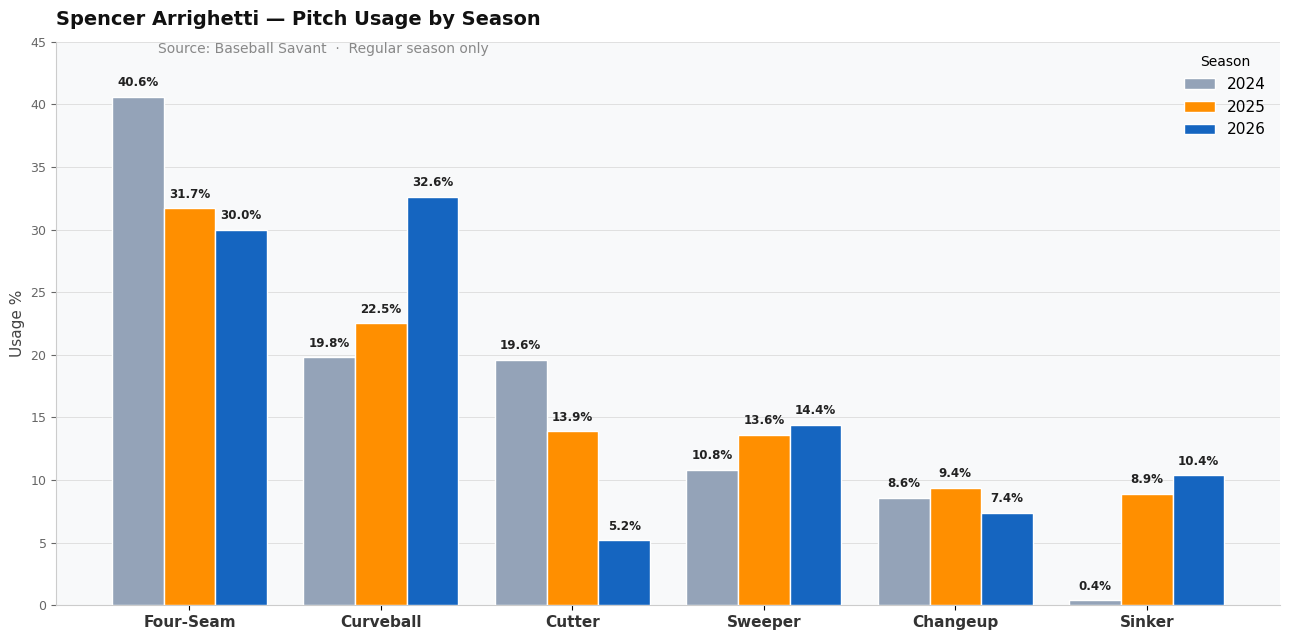

In [9]:
import matplotlib.pyplot as plt
import numpy as np

all_pitches = ['Four-Seam', 'Curveball', 'Cutter', 'Sweeper', 'Changeup', 'Sinker']

data = {
    '2024': {'Four-Seam':40.6, 'Curveball':19.8, 'Cutter':19.6, 'Sweeper':10.8, 'Changeup':8.6, 'Sinker':0.4},
    '2025': {'Four-Seam':31.7, 'Curveball':22.5, 'Cutter':13.9, 'Sweeper':13.6, 'Changeup':9.4, 'Sinker':8.9},
    '2026': {'Four-Seam':30.0, 'Curveball':32.6, 'Cutter':5.2,  'Sweeper':14.4, 'Changeup':7.4, 'Sinker':10.4},
}

# 시즌별 색상
season_colors = {
    '2024': '#94A3B8',   # 회색 — 과거
    '2025': '#FF8F00',   # 주황 — 중간
    '2026': '#1565C0',   # 진한 파랑 — 현재 (핵심)
}

fig, ax = plt.subplots(figsize=(13, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('#F8F9FA')

seasons = ['2024', '2025', '2026']
x = np.arange(len(all_pitches))
width = 0.27

for i, season in enumerate(seasons):
    values = [data[season][p] for p in all_pitches]
    offset = (i - 1) * width
    
    bars = ax.bar(
        x + offset, values, width,
        label=season,
        color=season_colors[season],
        edgecolor='white', linewidth=1,
        zorder=3,
    )
    
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.6,
            f"{val}%",
            ha='center', va='bottom',
            fontsize=8.5, fontweight='bold',
            color='#222'
        )

ax.set_xticks(x)
ax.set_xticklabels(all_pitches, fontsize=11, fontweight='bold', color='#333')

ax.set_ylim(0, 45)
ax.set_ylabel('Usage %', fontsize=11, color='#444')
ax.tick_params(axis='y', colors='#666', labelsize=9)
ax.yaxis.grid(True, color='#E0E0E0', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top','right']].set_visible(False)
ax.spines[['left','bottom']].set_color('#CCCCCC')

# 시즌 범례
ax.legend(
    loc='upper right',
    frameon=False,
    fontsize=11,
    title='Season',
    title_fontsize=10
)

ax.set_title(
    'Spencer Arrighetti — Pitch Usage by Season',
    fontsize=14, fontweight='bold', color='#111', pad=12, loc='left'
)
fig.text(
    0.125, 0.91,
    'Source: Baseball Savant  ·  Regular season only',
    fontsize=10, color='#888'
)

plt.tight_layout()
plt.savefig('arrighetti_pitch_usage.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [10]:
# ===========================================
# 카운트 그룹별 커브 구사율 (시즌 비교)
# ===========================================

def count_group(balls, strikes):
    if balls == 0 and strikes == 0:
        return 'First Pitch'
    elif strikes == 2:
        return 'Two-Strike'  # 0-2, 1-2, 2-2, 3-2
    elif balls > strikes:
        return 'Behind'      # 1-0, 2-0, 2-1, 3-0, 3-1
    elif balls == strikes:
        return 'Even'        # 1-1
    else:
        return 'Ahead'       # 0-1 (그 외 ahead는 위에서 처리됨)

def curve_by_count_group(df, season_label):
    d = df[df['game_type'] == 'R'].copy()
    d['group'] = d.apply(lambda r: count_group(int(r['balls']), int(r['strikes'])), axis=1)
    
    result = {}
    for group in ['First Pitch', 'Behind', 'Even', 'Ahead', 'Two-Strike']:
        sub = d[d['group'] == group]
        if len(sub) == 0:
            result[group] = 0
            continue
        cu_pct = (sub['pitch_type'] == 'CU').sum() / len(sub) * 100
        result[group] = round(cu_pct, 1)
    
    print(f"=== {season_label} 카운트 그룹별 커브 구사율 ===")
    for g, v in result.items():
        print(f"  {g:12s}: {v}%")
    print()
    return result

curve_2024 = curve_by_count_group(df_2024, '2024')
curve_2025 = curve_by_count_group(df_2025, '2025')
curve_2026 = curve_by_count_group(df_2026, '2026')

=== 2024 카운트 그룹별 커브 구사율 ===
  First Pitch : 23.6%
  Behind      : 10.6%
  Even        : 24.0%
  Ahead       : 16.1%
  Two-Strike  : 23.6%

=== 2025 카운트 그룹별 커브 구사율 ===
  First Pitch : 26.9%
  Behind      : 16.9%
  Even        : 14.0%
  Ahead       : 17.1%
  Two-Strike  : 28.4%

=== 2026 카운트 그룹별 커브 구사율 ===
  First Pitch : 23.6%
  Behind      : 26.5%
  Even        : 36.1%
  Ahead       : 36.0%
  Two-Strike  : 47.4%



In [7]:
# ===========================================
# 2026 정규시즌 전체 피안타 분석
# 그 중 포심으로 맞은 게 몇 개인지
# ===========================================

# 1. 전체 피안타 (모든 구종 합쳐서)
all_hits = df_2026[
    (df_2026['game_type'] == 'R') &
    (df_2026['events'].isin(['single', 'double', 'triple', 'home_run']))
][['game_date', 'pitch_type', 'launch_speed', 'launch_angle', 
   'events', 'bb_type']].reset_index(drop=True)

print(f"=== 2026 정규시즌 전체 피안타: {len(all_hits)}개 ===\n")

# 2. 구종별 피안타 카운트
print("=== 구종별 피안타 분포 ===")
pitch_hit_count = all_hits['pitch_type'].value_counts()
print(pitch_hit_count)
print()
print(f"포심(FF)으로 맞은 피안타: {pitch_hit_count.get('FF', 0)}개")
print(f"전체 피안타 중 포심 비율: {pitch_hit_count.get('FF', 0)/len(all_hits)*100:.1f}%")
print()

# 3. 포심 피안타 상세
ff_hits = all_hits[all_hits['pitch_type'] == 'FF'].reset_index(drop=True)

print("=== 포심 피안타 상세 (타구속도 / 발사각) ===")
display(ff_hits)

print(f"\n포심 피안타 평균 타구속도: {ff_hits['launch_speed'].mean():.1f} mph")
print(f"포심 피안타 평균 발사각  : {ff_hits['launch_angle'].mean():.1f}°")

=== 2026 정규시즌 전체 피안타: 27개 ===

=== 구종별 피안타 분포 ===
pitch_type
ST    6
FF    6
CU    4
CH    4
SI    4
FC    3
Name: count, dtype: int64

포심(FF)으로 맞은 피안타: 6개
전체 피안타 중 포심 비율: 22.2%

=== 포심 피안타 상세 (타구속도 / 발사각) ===


,game_date,pitch_type,launch_speed,launch_angle,events,bb_type
0,2026-05-22,FF,62.4,30.0,double,fly_ball
1,2026-05-09,FF,98.6,-1.0,single,ground_ball
2,2026-05-02,FF,101.0,20.0,single,line_drive
3,2026-05-02,FF,96.7,3.0,single,ground_ball
4,2026-04-26,FF,102.6,21.0,double,line_drive
5,2026-04-26,FF,101.7,12.0,single,line_drive



포심 피안타 평균 타구속도: 93.8 mph
포심 피안타 평균 발사각  : 14.2°
